# Quickstart

Run the reference week, look at what the naive household does to the feeder, and
score your own idea.

Everything below takes about a minute end to end.

In [1]:
%load_ext autoreload
%autoreload 2

# Picks up edits to sandbox/*.py (my_idea, controller, tariff, ...) on the next
# cell run -- no kernel restart needed. Edit sandbox/my_idea.py, re-run cell 12,
# and you will see the change.

In [2]:
import jax
import jax.numpy as jnp

from sandbox.controller import base_controller, passive_controller
from sandbox.metrics import compare, score
from sandbox.rollout import build_env, rollout
from sandbox.scenarios import end_of_line_impedance_ohm, reference_scenario

population = reference_scenario()
env = build_env(population)

print(f"{population.num_pq} connection points, {population.num_agents} of them agents")
print(f"end-of-line impedance: {end_of_line_impedance_ohm():.3f} ohm")
for name in ("tenant", "pv_only", "pv_battery", "large_flex"):
    print(f"  {name:<12} {population.type_of_pq.count(name)}")

18 connection points, 12 of them agents
end-of-line impedance: 0.912 ohm
  tenant       6
  pv_only      2
  pv_battery   6
  large_flex   4


## The pathology

`passive` never touches the battery. `self_consumption` is what every home
battery ships with. Watch the **ramp** column.

In [3]:
scores = {}
for controller in (passive_controller(), base_controller()):
    trajectory = rollout(controller, population, jax.random.PRNGKey(0), env=env)
    scores[controller.name] = score(trajectory, population)

print(compare(scores))

                   export_pk_kW   draw_pk_kW      reverse      coincid      ramp_kW         corr         loss      curtail     selfcons          CHF        >1.05
-----------------------------------------------------------------------------------------------------------------------------------------------------------------
passive                    69.4         18.4          46%        0.805          6.9        +0.67        8.82%         0.8%          14%          299       12.98%
self_consumption           66.8          8.2          41%        0.773         16.1        +0.24        9.09%         1.4%          28%          332       10.49%


Self-consumption is better for the household on every count it can see — a
bigger cheque, more solar used behind the meter — and makes the steepest swing
at the transformer **2.3× worse**. Every battery fills at the same moment, so
every battery stops absorbing at the same moment.

No price is involved. The correlation is in the weather and the working day.

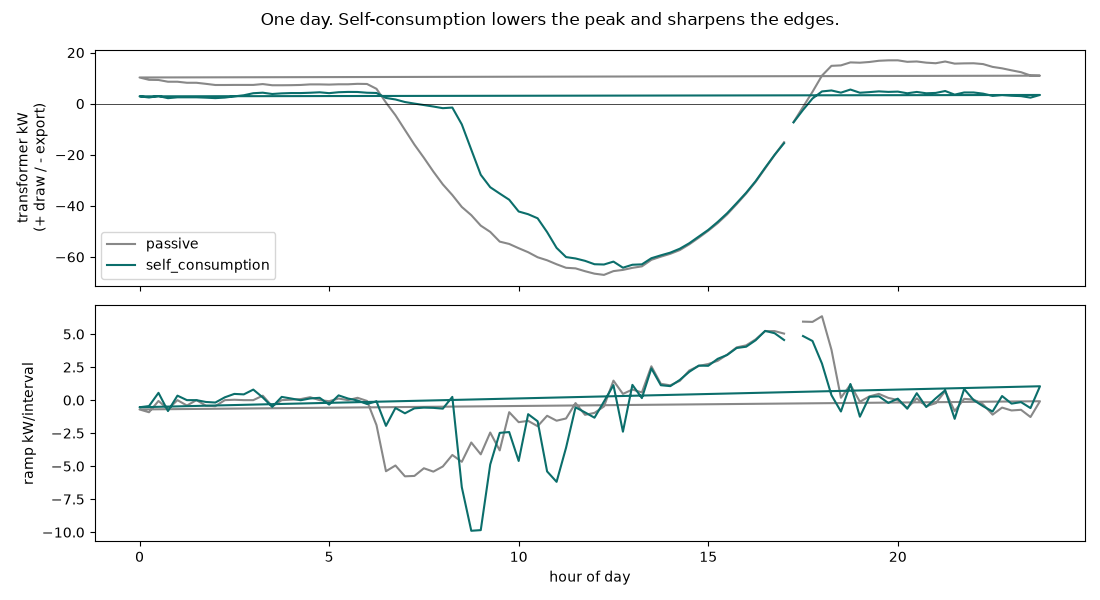

In [4]:
import matplotlib.pyplot as plt

from sandbox.export import feeder_dataframe

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for controller, colour in ((passive_controller(), "#888"), (base_controller(), "#0b6e6b")):
    trajectory = rollout(controller, population, jax.random.PRNGKey(0), env=env)
    feeder = feeder_dataframe(trajectory).query("day == 2")
    axes[0].plot(feeder.hour, feeder.transformer_kw, color=colour, label=controller.name)
    axes[1].plot(feeder.hour[1:], feeder.transformer_kw.diff()[1:], color=colour)

axes[0].set_ylabel("transformer kW\n(+ draw / - export)")
axes[0].legend()
axes[0].axhline(0, lw=0.5, color="k")
axes[1].set_ylabel("ramp kW/interval")
axes[1].set_xlabel("hour of day")
fig.suptitle("One day. Self-consumption lowers the peak and sharpens the edges.")
plt.tight_layout()

## What one household can see

No price anywhere in it. Note which interval each field describes: `p_load_kw`
and `voltage_pu` are what just happened, `p_load_forecast_kw` and
`pv_available_kw` are the interval you are about to act in.

The controller returns the **inverter**'s power, `p_inv_kw`. What the feeder
carries — and what the tariff settles — is `p_inv_kw - p_load_kw`.

In [5]:
from sandbox.observation import to_local

state, timestep = env.reset(jax.random.PRNGKey(0))
local = to_local(env.environment, timestep.observation, state)

for name, values in local.as_dict().items():
    print(f"{name:<22} {jnp.round(values[:4], 2)}")

hour                   [3.5 3.5 3.5 3.5]
time_sin               [0.81 0.81 0.81 0.81]
time_cos               [0.58 0.58 0.58 0.58]
voltage_pu             [0.97999996 0.97999996 0.97999996 0.97999996]
p_grid_kw               [-0.55      -1.4       -1.9599999  3.37     ]
p_load_kw                [0.55       0.39       0.17999999 0.14999999]
p_load_forecast_kw       [0.48999998 0.28       0.17       0.14999999]
pv_available_kw        [0. 0. 0. 0.]
soc_kwh                [0.         9.04       3.1899998  0.78999996]
soc_headroom_kwh       [ 0.         3.9599998  9.809999  12.21     ]
bat_charge_max_kw      [0. 5. 5. 5.]
bat_discharge_max_kw   [0.        5.        5.        3.1499999]
p_inv_min_kw               [-0. -5. -5. -5.]
p_inv_max_kw               [0.        5.        5.        3.1499999]


## What the network can see

The tariff's turn: after the interval solves, it sees the whole feeder, not
one meter. `grid.e_grid_kwh` is each connection point's net **active**
exchange with the grid, inverter output minus household load — the quantity
the baseline settles.

A network operator also measures **reactive** power, so `grid.q_grid_kvar`
and `grid.transformer_kvar` are here too. A household never chooses those
(the Q(U) grid code does), which makes pricing them a trap worth reading
about in [`TARIFF_COOKBOOK.md`](../TARIFF_COOKBOOK.md) before you try.

`grid.fair_leg_chf` is zero here, because this cell steps the model directly
with no tariff in the loop; in a real rollout it is the finished CHF
settlement the fair-LEG baseline would produce.

In [6]:
from sandbox.observation import to_grid_view

model = env.environment
new_state, _ = model.step(state, jnp.zeros((model.num_agents, model.action_dim), jnp.float32))
grid = to_grid_view(model, new_state)

for name, values in (
    ("e_grid_kwh", grid.e_grid_kwh),
    ("p_grid_kw", grid.p_grid_kw),
    ("q_grid_kvar", grid.q_grid_kvar),
    ("voltage_pu", grid.voltage_pu),
):
    print(f"{name:<14} {jnp.round(values[:4], 2)}")
print(f"{'transformer':<14} {grid.transformer_kw:.2f} kW   {grid.transformer_kvar:.2f} kvar")

e_grid_kwh      [-0.07 -0.04 -0.09 -0.06]
voltage_pu   [1.         1.         1.         0.98999995]
transformer_kw 7.09


## Now make it yours

Open **`sandbox/my_idea.py`**. Two functions, both naive working defaults you
are meant to overwrite -- a household controller and a grid tariff (a full
settlement, not a bolt-on charge). Edit either or both, then run the cell
below.

`check()` takes about ten seconds and is for iterating. On a fresh checkout it
prints five identical rows and says so: the default `my_controller` *is* the
reference controller.

**`check()` does not tune, so it cannot show a tariff working** — no household
sees a price during an episode. `score()` re-tunes households against your
tariff first, runs the full week over twenty weathers, and takes about three
minutes. It is what the jury sees.

For more room than one function each: [`CONTROLLER_COOKBOOK.md`](../CONTROLLER_COOKBOOK.md)
and [`TARIFF_COOKBOOK.md`](../TARIFF_COOKBOOK.md).

In [7]:
from sandbox.my_idea import check

check(days=3)

            export_pk_kW      coincid      ramp_kW      curtail          CHF
----------------------------------------------------------------------------
reference           64.2        0.771         11.5         0.6%          127
yours               64.2        0.771         11.5         0.6%          127

  solar exported at the worst moment      64.21 ->    64.21 kW    same
  worst sudden swing (herding)            11.54 ->    11.54 kW    same
  everyone acting at once                  0.77 ->     0.77       same
  solar thrown away                        0.57 ->     0.57 %     same
  what the households earned             126.86 ->   126.86 CHF   same

  one weather, 3 day(s) -- rough. `score()` runs the real thing.


## Debugging

`fast=False` swaps the scan for a Python loop and the vmap for a list
comprehension. Values become concrete, so `if` and `print` work and the
traceback points at your line. Same answer; about 100× slower per interval,
which is `check()`'s ten seconds becoming eighty.

Or write the whole thing in NumPy — see `sandbox/numpy_bridge.py`. That tier
is for prototyping: it costs about 8× on a tuning sweep, so port to `jnp`
before you start iterating on `score()`.

In [8]:
trajectory = rollout(
    base_controller(), population, jax.random.PRNGKey(0), n_steps=8, env=env, fast=False
)
print("p_inv_kw, first interval:", jnp.round(trajectory.p_inv_set_kw[0], 2))

p_inv_kw, first interval: [0.78999996 0.25       0.71       0.77       0.03       0.29999998
 2.06       1.8399999  1.52       0.08       0.68       0.7       ]


## Out to pandas

No JAX beyond this point — the fairness audit and any visualisation can be done
entirely in tools you already know. All eighteen connection points are here,
tenants included; they have no agent and are missing from anything indexed by
one. `distance_rank` orders them by electrical distance from the transformer,
0 nearest.

In [9]:
from sandbox.export import to_dataframe

trajectory = rollout(base_controller(), population, jax.random.PRNGKey(0), env=env)
frame = to_dataframe(trajectory, population, label="self_consumption")

frame.groupby("household").agg(
    settlement_chf=("settlement_chf", "sum"),
    mean_grid_kw=("p_grid_kw", "mean"),
    mean_grid_kvar=("q_grid_kvar", "mean"),
    mean_inverter_kw=("p_inv_set_kw", "mean"),
    peak_voltage_pu=("voltage_pu", "max"),
).round(2)

,settlement_chf,mean_meter_kw,peak_voltage_pu
household,,,
large_flex,124.129997,1.43,1.11
pv_battery,273.420013,2.01,1.08
pv_only,18.080000,0.53,1.06
tenant,-83.790001,-0.37,1.05
